In [ ]:
# Сжатый повтор элементов части 1, нужных для этой части проекта
import pandas as pd
import matplotlib.pyplot as plt

red = pd.read_csv('winequality-red.csv', sep=';')
white = pd.read_csv('winequality-white.csv', sep=';')
red['type'] = 'red'
white['type'] = 'white'
wine = pd.concat([red, white], ignore_index=True)

chem_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
             'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
             'density', 'pH', 'sulphates', 'alcohol']

wine_work = wine.drop_duplicates().reset_index(drop=True)

# Сравнение красного и белого вина
План раздела:
1. Разделение выборки на красное и белое.
2. Сравнение распределений хим.признаков по типам вина.
3. Сравнение средней оценки качества.
4. Статистическая проверка различий признаков между типами (Манна–Уитни).
5. Сравнение корреляций между признаками и итоговым значением качества

## 1. Разделение выборки на красное и белое

In [ ]:
from scipy import stats
red_work = wine_work[wine_work['type'] == 'red'].copy()
white_work = wine_work[wine_work['type'] == 'white'].copy()
print('Красное вино:', red_work.shape)
print('Белое вино:  ', white_work.shape)
print('Доля красного:', round(len(red_work) / len(wine_work) * 100, 1), '%')

Красное вино: (1359, 13)
Белое вино:   (3961, 13)
Доля красного: 25.5 %


## 2. Сравнение распределений химических признаков

In [ ]:
feat_compare = pd.DataFrame({ 'red_mean': red_work[chem_cols].mean(), 'white_mean': white_work[chem_cols].mean(),})
feat_compare['ratio_red_to_white'] = (feat_compare['red_mean'] / feat_compare['white_mean']).round(2)
feat_compare = feat_compare.round(3)
display(feat_compare.sort_values('ratio_red_to_white', ascending=False))

,red_mean,white_mean,ratio_red_to_white
chlorides,0.088,0.046,1.92
volatile acidity,0.529,0.281,1.89
sulphates,0.659,0.490,1.34
fixed acidity,8.311,6.839,1.22
pH,3.310,3.195,1.04
density,0.997,0.994,1.00
alcohol,10.432,10.589,0.99
citric acid,0.272,0.334,0.81
free sulfur dioxide,15.893,34.889,0.46
residual sugar,2.523,5.915,0.43


Выводы:
У красного вина в 1.9 раза выше летучая кислотность и  хлориды, и примерно в 1.2 - 1.3 выше сульфаты и фиксированная кислотность. У белого вина же существенно больше остаточного сахара и диоксида серы - в 2 - 3 раза. По содержанию алкоголя и плотности оба вида схожи.

## 3. Сравнение средней оценки качества по типам


In [ ]:
quality_by_type = pd.DataFrame({
    'count': wine_work.groupby('type')['quality'].size(),
    'mean_quality': wine_work.groupby('type')['quality'].mean().round(3),
    'median_quality': wine_work.groupby('type')['quality'].median(),
    'std_quality': wine_work.groupby('type')['quality'].std().round(3),
})
display(quality_by_type)
u_stat, p_value = stats.mannwhitneyu(red_work['quality'], white_work['quality'], alternative='two-sided')
print('Тест Манна-Уитни (quality red vs white):')
print('  U =', round(u_stat, 1), ' p-value =', format(p_value, '.2e'))
print('  Различие', 'значимо' if p_value < 0.05 else 'не значимо', '(уровень 0.05)')

,count,mean_quality,median_quality,std_quality
type,,,,
red,1359,5.623,6.0,0.824
white,3961,5.855,6.0,0.891


Тест Манна-Уитни (quality red vs white):
  U = 2290875.0  p-value = 2.00e-18
  Различие значимо (уровень 0.05)


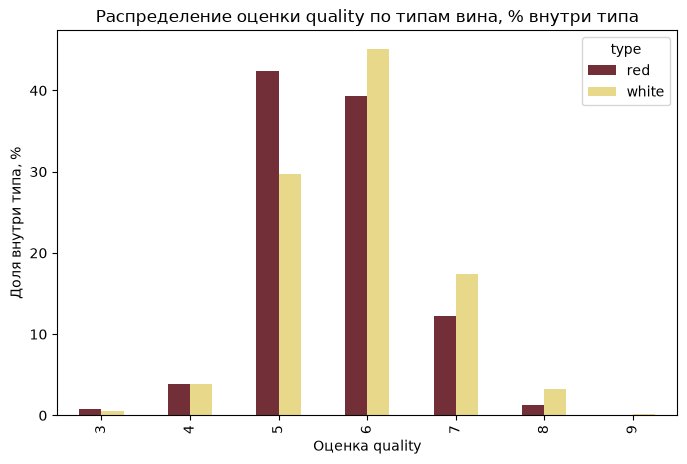

In [ ]:
quality_share = pd.crosstab(wine_work['quality'], wine_work['type'], normalize='columns') * 100
quality_share.plot(kind='bar', figsize=(8, 5), color=['#722F37', '#E8D98A'])
plt.title('Распределение оценки quality по типам вина, % внутри типа')
plt.xlabel('Оценка quality')
plt.ylabel('Доля внутри типа, %')
plt.show()

Вывод: Средняя оценка белого вина чуть выше, чем красного, а тест Манна–Уитни подтверждает, что различие статистически значимо. Медиана у обоих типов равна 6. Оба распределения больше всего концентрируются на  на оценках 5 и 6, а крайних значений мало

Далее нам важно будет определить какие именно химичсекие признаки влияют на повышение quality

## 4. Статистическая проверка различий признаков между типами

Для каждого признака сравним его значения у красного и белого вина с помощью теста Манна–Уитни . Дополнительно считаем рранговую бисериальную корреляцию: чем ближе к 1, тем сильнее признак разделяет два типа.

In [ ]:
n_red, n_white = len(red_work), len(white_work)
rows = []
for col in chem_cols:
    u, p = stats.mannwhitneyu(red_work[col], white_work[col], alternative='two-sided')
    rank_biserial = abs(1 - 2 * u / (n_red * n_white))
    rows.append([col, round(red_work[col].median(), 3), round(white_work[col].median(), 3),
                 p, round(rank_biserial, 3)])
diff_test = pd.DataFrame(rows, columns=['feature', 'red_median', 'white_median', 'p_value', 'effect_size'])
diff_test['significant'] = diff_test['p_value'] < 0.05
display(diff_test.sort_values('effect_size', ascending=False).reset_index(drop=True))
print('Значимо различаются:', int(diff_test['significant'].sum()), 'из', len(diff_test), 'признаков')

,feature,red_median,white_median,p_value,effect_size,significant
0,total sulfur dioxide,38.000,133.000,0.000000e+00,0.899,True
1,chlorides,0.079,0.042,0.000000e+00,0.884,True
2,volatile acidity,0.520,0.260,0.000000e+00,0.796,True
3,free sulfur dioxide,14.000,33.000,1.485516e-310,0.684,True
4,sulphates,0.620,0.480,2.315134e-290,0.661,True
5,density,0.997,0.994,6.050929e-240,0.600,True
6,fixed acidity,7.900,6.800,4.014550e-215,0.568,True
7,pH,3.310,3.180,1.102964e-119,0.422,True
8,residual sugar,2.200,4.700,8.679831e-58,0.291,True
9,citric acid,0.260,0.320,1.210649e-30,0.209,True


Значимо различаются: 11 из 11 признаков


Вывод: Для всех признаков(p < 0.05). Сильнее всего типы разделяют total sulfur dioxide, chlorides и volatile acidity, что значит что по ним можно в большинстве случаев однозначно определить тип вина . Слабее всего разделяет alcohol, то есть  крепость у двух типов почти одинаковая.

## 5. Сравнение корреляций признаков и итогового качества по типам
Теперь мы готовы проверить главный вопрос . Считаем корреляцию каждого химического признака с quality отдельно для красного и белого вина и сравниваем, какие признаки сильнее влияют на качество у каждого типа.

In [ ]:
corr_red = red_work[chem_cols + ['quality']].corr()['quality'].drop('quality')
corr_white = white_work[chem_cols + ['quality']].corr()['quality'].drop('quality')
corr_by_type = pd.DataFrame({'red_corr': corr_red, 'white_corr': corr_white})
corr_by_type['diff'] = corr_by_type['red_corr'] - corr_by_type['white_corr']
corr_by_type['same_sign'] = (corr_by_type['red_corr'] * corr_by_type['white_corr']) > 0
corr_by_type = corr_by_type.round(3)
display(corr_by_type.reindex(corr_red.abs().sort_values(ascending=False).index))

,red_corr,white_corr,diff,same_sign
alcohol,0.480,0.463,0.017,True
volatile acidity,-0.395,-0.191,-0.205,True
sulphates,0.249,0.053,0.196,True
citric acid,0.228,0.007,0.221,True
density,-0.184,-0.338,0.154,True
total sulfur dioxide,-0.178,-0.183,0.006,True
chlorides,-0.131,-0.218,0.087,True
fixed acidity,0.119,-0.125,0.244,False
pH,-0.055,0.124,-0.179,False
free sulfur dioxide,-0.050,0.011,-0.061,False


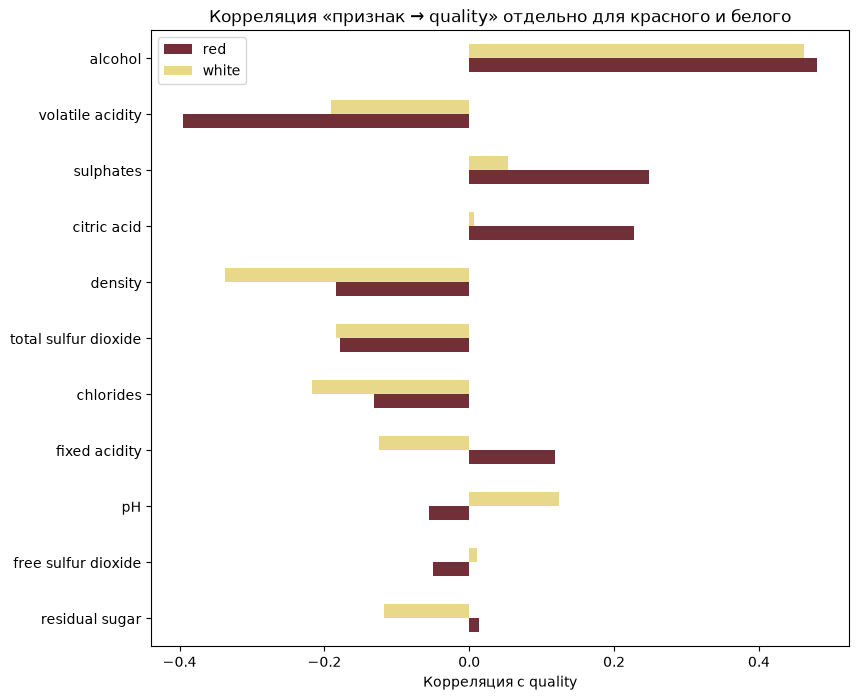

In [ ]:
corr_plot = pd.DataFrame({'red': corr_red, 'white': corr_white})
corr_plot = corr_plot.reindex(corr_red.abs().sort_values().index)
corr_plot.plot(kind='barh', figsize=(9, 8), color=['#722F37', '#E8D98A'])
plt.xlabel('Корреляция с quality')
plt.title('Корреляция «признак → quality» отдельно для красного и белого')
plt.show()

Итоги:

Общие признаки:
- alcohol - самый сильный положительный параметр качества и у красного, и у белого (corr = +0.48 / +0.46). Это главный общий признак.
- volatile acidity — связан с качеством отрицательно у обоих типов, но у красного эта связь заметно сильнее.
- density и chlorides понижают качество  у обоих типов.

Отличается:
- У красного вина важны sulphates и citric acid  — у белого их связь с качеством очень низкая.
- У белого вина заметен  отрицательный вклад параметра density  и chlorides, а также положительная роль pH.
- У части признаков знак связи противоположный : fixed acidity, residual sugar, pH, free sulfur dioxide  то есть они по разному  влияют на качество у двух типов.